In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV

In [2]:
data = pd.read_excel(r'/kaggle/input/complete-blood-count-cbc-test/cbc information.xlsx')

In [3]:
data['anemia'] = (data['HGB'] < 11.0).astype(int)

In [4]:
features = ['WBC', 'LYMp', 'MIDp', 'NEUTp', 'LYMn', 'MIDn', 'NEUTn', 
            'RBC', 'HCT', 'MCV', 'MCH', 'MCHC', 'RDWSD', 'RDWCV', 
            'PLT', 'MPV', 'PDW', 'PCT', 'PLCR']


In [5]:
X = data[features]
y = data['anemia']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [9]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(kernel='rbf')
}

In [10]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    print(f"\n{name} Performance:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


Logistic Regression Performance:
Accuracy: 0.86
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.98      0.88        54
           1       0.97      0.72      0.82        46

    accuracy                           0.86       100
   macro avg       0.89      0.85      0.85       100
weighted avg       0.88      0.86      0.86       100

Confusion Matrix:
[[53  1]
 [13 33]]

Random Forest Performance:
Accuracy: 0.94
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        54
           1       0.93      0.93      0.93        46

    accuracy                           0.94       100
   macro avg       0.94      0.94      0.94       100
weighted avg       0.94      0.94      0.94       100

Confusion Matrix:
[[51  3]
 [ 3 43]]

SVM Performance:
Accuracy: 0.82
Classification Report:
              precision    recall  f1-score   support

           0       0.76

In [11]:
# Using Random Forest for feature importance
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)

importances = rf.feature_importances_
feature_importance = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance = feature_importance.sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)


Feature Importance:
   Feature  Importance
8      HCT    0.395438
7      RBC    0.162986
11    MCHC    0.119166
10     MCH    0.086531
9      MCV    0.054176
13   RDWCV    0.040782
12   RDWSD    0.020684
2     MIDp    0.013678
14     PLT    0.012879
3    NEUTp    0.011372
4     LYMn    0.010489
5     MIDn    0.010471
0      WBC    0.010346
6    NEUTn    0.009758
17     PCT    0.009658
16     PDW    0.008471
15     MPV    0.008239
18    PLCR    0.007601
1     LYMp    0.007275


In [12]:


# Optimize Random Forest
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), 
                          param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

# Evaluate optimized model
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test_scaled)
print("\nOptimized Random Forest Performance:")
print(classification_report(y_test, y_pred))

Best parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 300}
Best score: 0.9674999999999999

Optimized Random Forest Performance:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95        54
           1       0.96      0.93      0.95        46

    accuracy                           0.95       100
   macro avg       0.95      0.95      0.95       100
weighted avg       0.95      0.95      0.95       100



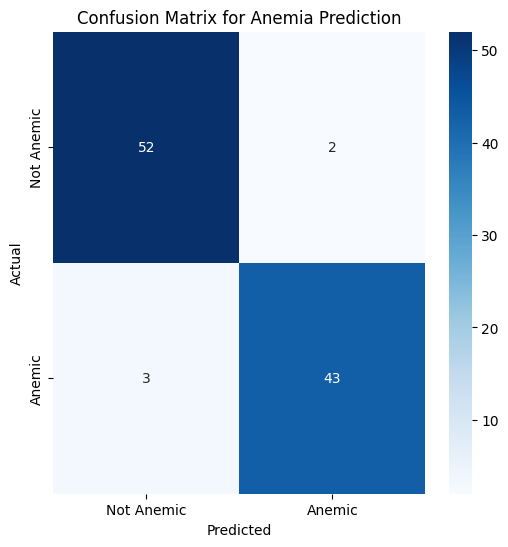

In [13]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Anemic', 'Anemic'], 
            yticklabels=['Not Anemic', 'Anemic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Anemia Prediction')
plt.show()

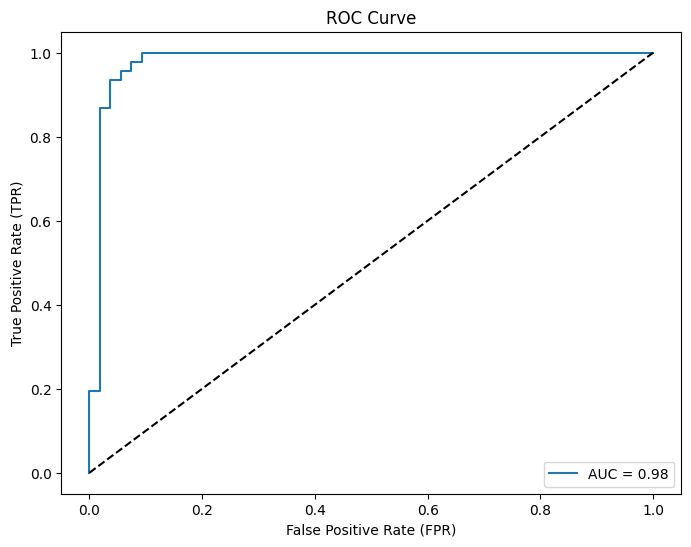

In [14]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities
y_probs = best_rf.predict_proba(X_test_scaled)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
plt.plot([0, 1], [0, 1], 'k--')  # Random guess line
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend()
plt.show()

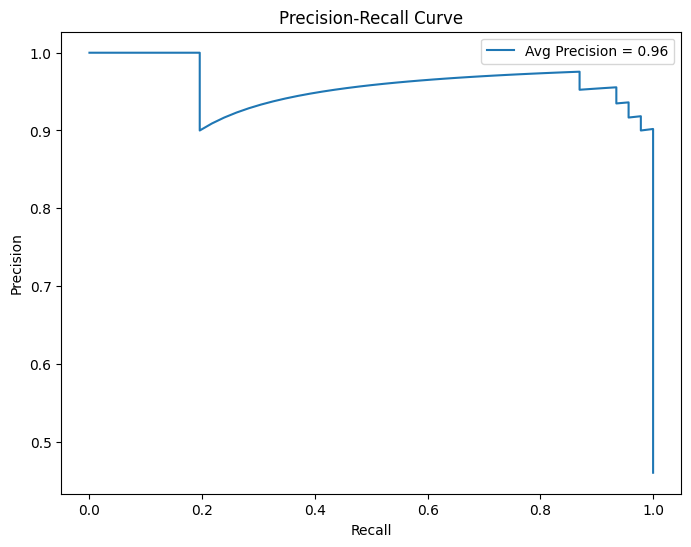

In [15]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_probs)
avg_precision = average_precision_score(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Avg Precision = {avg_precision:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

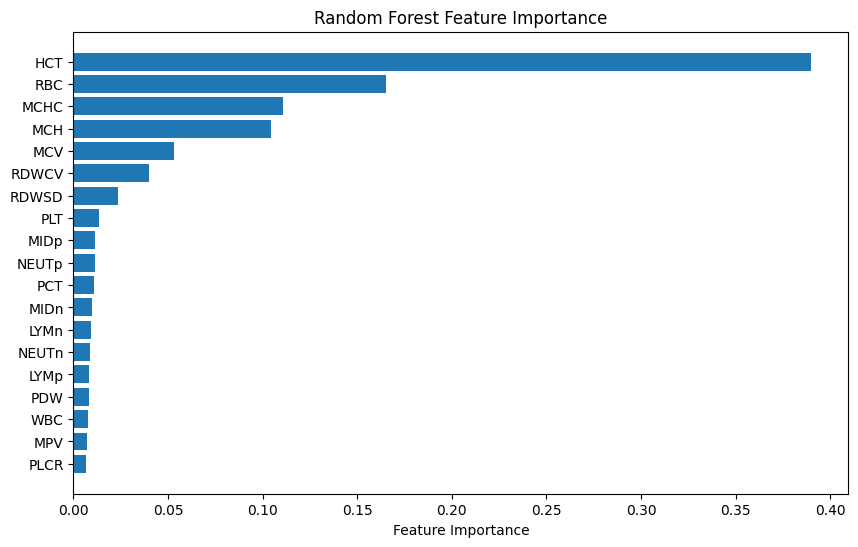

In [16]:
importances = best_rf.feature_importances_
feature_names = features

# Sort features by importance
sorted_idx = importances.argsort()

# Plot
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), importances[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.show()

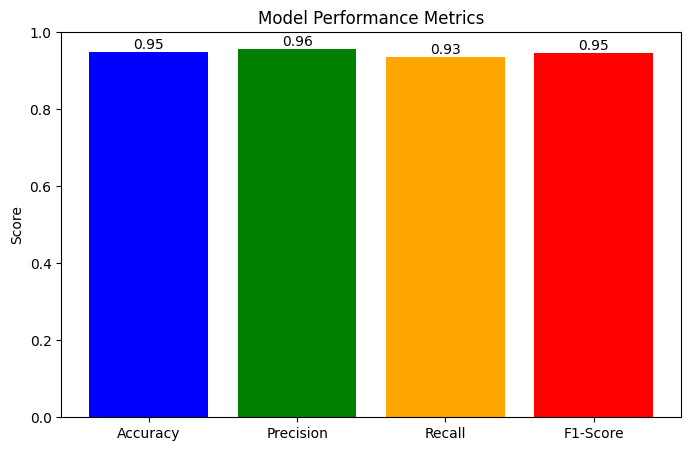

In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Compute metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [accuracy, precision, recall, f1]

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(metrics, values, color=['blue', 'green', 'orange', 'red'])
plt.ylim(0, 1)
plt.title('Model Performance Metrics')
plt.ylabel('Score')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}', ha='center', va='bottom')

plt.show()

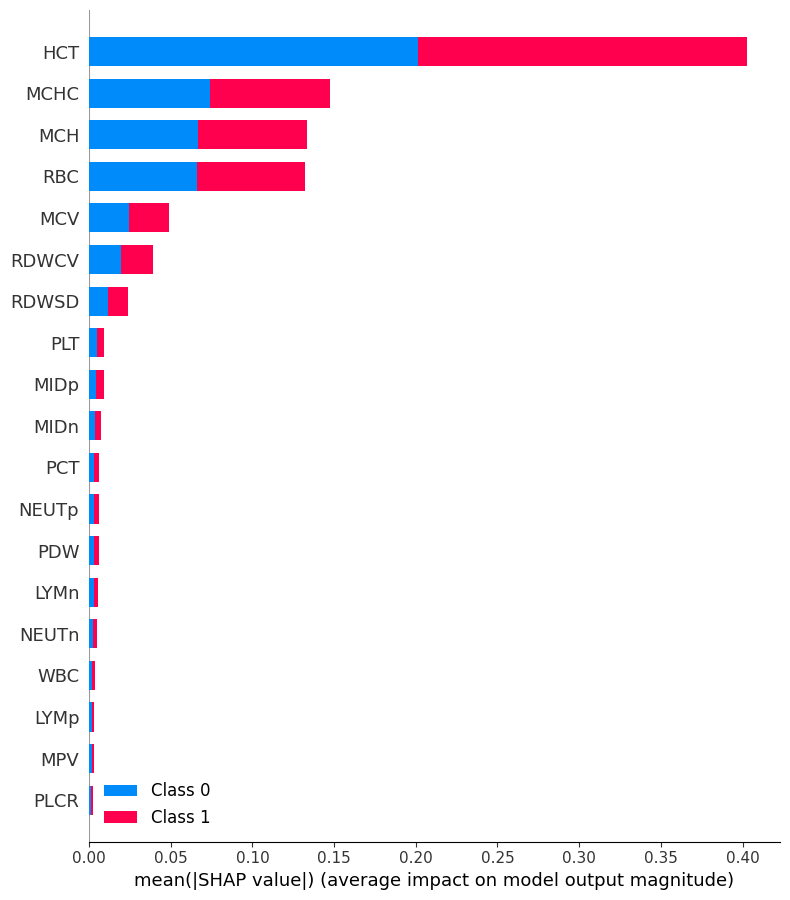

In [18]:
import shap

# Explain model predictions
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test_scaled)

# Visualize feature importance
shap.summary_plot(shap_values, X_test, feature_names=features)

In [19]:
import joblib  # or import pickle

# Save the trained model to a file
model_filename = 'anemia_prediction_rf_model.pkl'
joblib.dump(best_rf, model_filename)

# Alternatively, using pickle:
# import pickle
# with open('anemia_prediction_rf_model.pkl', 'wb') as f:
#     pickle.dump(best_rf, f)

print(f"Model saved as {model_filename}")

Model saved as anemia_prediction_rf_model.pkl
